# **Capstone Project: Sentiment-Based Product Recommendation System**

#                                               **Problem Statement**

The e-commerce business is quite popular today. Here, you do not need to take orders by going to each customer. A company launches its website to sell the items to the end consumer, and customers can order the products that they require from the same website. Famous examples of such e-commerce companies are Amazon, Flipkart, Myntra, Paytm and Snapdeal.

Suppose you are working as a Machine Learning Engineer in an e-commerce company named 'Ebuss'. Ebuss has captured a huge market share in many fields, and it sells the products in various categories such as household essentials, books, personal care products, medicines, cosmetic items, beauty products, electrical appliances, kitchen and dining products and health care products.

With the advancement in technology, it is imperative for Ebuss to grow quickly in the e-commerce market to become a major leader in the market because it has to compete with the likes of Amazon, Flipkart, etc., which are already market leaders.

As a senior ML Engineer, you are asked to build a model that will improve the recommendations given to the users given their past reviews and ratings.

In order to do this, you planned to build a sentiment-based product recommendation system, which includes the following tasks.

Data sourcing and sentiment analysis Building a recommendation system Improving the recommendations using the sentiment analysis model Deploying the end-to-end project with a user interface



## 1. **Project Overview**
The objective of this project is to build an end-to-end recommendation engine for 'Ebuss', an e-commerce platform. The system will leverage collaborative filtering to suggest products and use a sentiment analysis model to refine those suggestions, ensuring only products with high positive sentiment reach the user.


In [1]:
#General Purpose Libraries 
import re
import time
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle


In [2]:
from collections import Counter
from datetime import datetime
import warnings
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
warnings.filterwarnings("ignore") 
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 300)
pd.set_option("display.precision", 2)

In [3]:
# NLTK libraries
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk import FreqDist
from nltk.tokenize import word_tokenize
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import wordnet

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Administrator\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [4]:
#Modelling 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score,confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

In [5]:
import sklearn
print("sklearn_version:",sklearn.__version__)
print("numpy_version:",np.__version__)
print("pd_version:",pd.__version__)
print("nltk_version:",nltk.__version__)

sklearn_version: 1.8.0
numpy_version: 2.4.4
pd_version: 3.0.2
nltk_version: 3.9.4


## **Task 1: Data Sourcing and Pre-Processing**

### 1.1 Data Quality checks

In this phase, we perform a rigorous audit of the `sample30.csv` dataset.

We will identify data quality issues, handle missing information, and prune the feature set to keep only those variables that contribute to our modeling goals.

In [6]:
# Configure visual settings
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load dataset
try:
    df = pd.read_csv('sample30.csv')
    print('Dataset "sample30" loaded successfully with {} rows and {} columns.'.format(df.shape[0], df.shape[1]))
except FileNotFoundError:
    print("Error: The file 'sample30.csv' was not found.")

df.head()

Dataset "sample30" loaded successfully with 30000 rows and 15 columns.


,id,brand,categories,manufacturer,name,reviews_date,reviews_didPurchase,reviews_doRecommend,reviews_rating,reviews_text,reviews_title,reviews_userCity,reviews_userProvince,reviews_username,user_sentiment
0,AV13O1A8GV-KLJ3akUyj,Universal Music,"Movies, Music & Books,Music,R&b,Movies & TV,Movie Bundles & Collections,CDs & Vinyl,Rap & Hip-Hop,Bass,Music on CD or Vinyl,Rap,Hip-Hop,Mainstream Rap,Pop Rap",Universal Music Group / Cash Money,Pink Friday: Roman Reloaded Re-Up (w/dvd),2012-11-30T06:21:45.000Z,NaN,NaN,5,i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.,Just Awesome,Los Angeles,NaN,joshua,Positive
1,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor. This review was collected as part of a promotion.,Good,NaN,NaN,dorothy w,Positive
2,AV14LG0R-jtxr-f38QfS,Lundberg,"Food,Packaged Foods,Snacks,Crackers,Snacks, Cookies & Chips,Rice Cakes,Cakes",Lundberg,Lundberg Organic Cinnamon Toast Rice Cakes,2017-07-09T00:00:00.000Z,True,NaN,5,Good flavor.,Good,NaN,NaN,dorothy w,Positive
3,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-01-06T00:00:00.000Z,False,False,1,"I read through the reviews on here before looking in to buying one of the couples lubricants, and was ultimately disappointed that it didn't even live up to the reviews I had read. For starters, neither my boyfriend nor I could notice any sort of enhanced or 'captivating' sensation. What we did ...",Disappointed,NaN,NaN,rebecca,Negative
4,AV16khLE-jtxr-f38VFn,K-Y,"Personal Care,Medicine Cabinet,Lubricant/Spermicide,Health,Sexual Wellness,Lubricants",K-Y,K-Y Love Sensuality Pleasure Gel,2016-12-21T00:00:00.000Z,False,False,1,My husband bought this gel for us. The gel caused irritation and it felt like it was burning my skin. I wouldn't recommend this gel.,Irritation,NaN,NaN,walker557,Negative


## **1.2 Data Inspection**

### Initial Data Quality Audit
Before cleaning, we must inspect the 'health' of the data. 

In the below code we will check for:
1. **Schema Integrity:** Do the datatypes match the expected values?
2. **Missingness:** Which columns are too sparse to be useful?
3. **Target Health:** Is the `user_sentiment` variable complete?

--- Schema Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    30000 non-null  str   
 1   brand                 30000 non-null  str   
 2   categories            30000 non-null  str   
 3   manufacturer          29859 non-null  str   
 4   name                  30000 non-null  str   
 5   reviews_date          29954 non-null  str   
 6   reviews_didPurchase   15932 non-null  object
 7   reviews_doRecommend   27430 non-null  object
 8   reviews_rating        30000 non-null  int64 
 9   reviews_text          30000 non-null  str   
 10  reviews_title         29810 non-null  str   
 11  reviews_userCity      1929 non-null   str   
 12  reviews_userProvince  170 non-null    str   
 13  reviews_username      29937 non-null  str   
 14  user_sentiment        29999 non-null  str   
dtypes: int64(1), object(2),

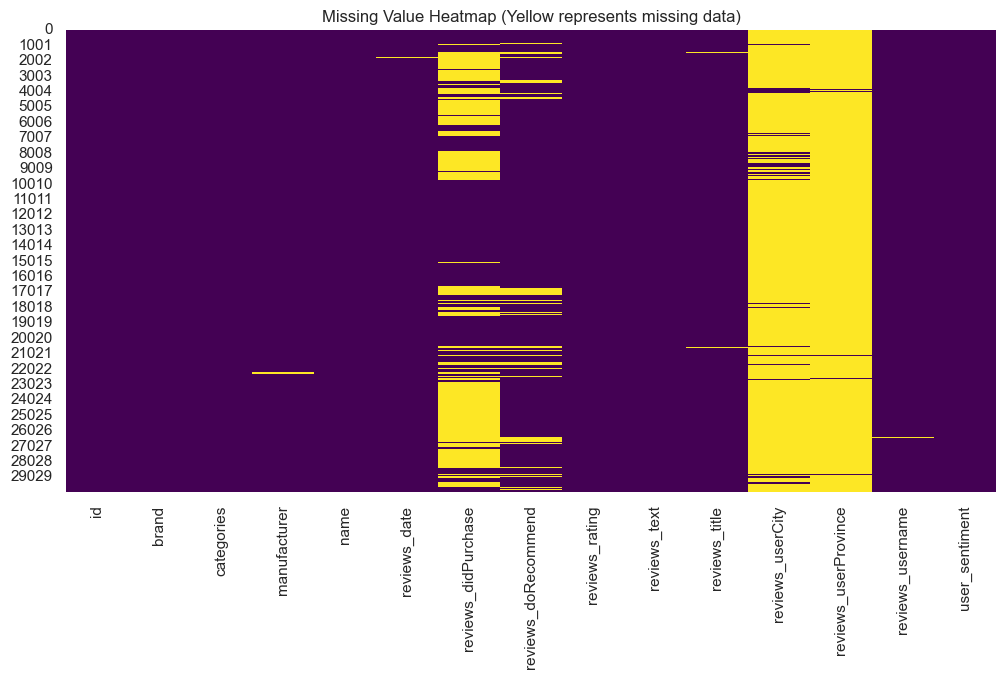

In [7]:
# 1. Summary of datatypes and non-null counts
print("--- Schema Overview ---")
print(df.info())

# 2. Detailed missing value analysis
missing_data = df.isnull().sum()
missing_perc = (missing_data / len(df)) * 100
missing_report = pd.concat([missing_data, missing_perc], axis=1, keys=['Total Missing', 'Percentage (%)'])
print("\n--- Missing Value Report ---")
print(missing_report.sort_values(by='Percentage (%)', ascending=False))

# 3. Visualizing Missing Values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap (Yellow represents missing data)")
plt.show()

### 1.3 Data Cleaning and Feature Pruning
Based on the audit above, we apply the following cleaning logic:

######
| Action | Columns Affected | Rationale |
| :--- | :--- | :--- |
| **Drop Columns** | reviews_userCity, reviews_userProvince, reviews_didPurchase | High percentage of missing values (>40% to 99%). These cannot be imputed reliably. |
| **Drop Columns** | id, brand, categories, manufacturer, reviews_date | Metadata that does not impact user-rating patterns or textual sentiment. |
| **Drop Rows** | reviews_username, user_sentiment | These are the 'keys' for our recommendation and sentiment models. Rows without them are unusable. |
| **Impute Values** | reviews_title | We fill nulls with a space " " to facilitate merging with the main review text. |
| **Type Conversion**| reviews_rating | Explicitly converted to integer for mathematical consistency. |

In [8]:
# 1. Dropping irrelevant or sparse columns
# Explanation: We prune metadata and location fields to reduce noise and memory footprint.
cols_to_remove = ['id', 'brand', 'categories', 'manufacturer', 'reviews_date', 
                  'reviews_didPurchase', 'reviews_userCity', 'reviews_userProvince']
                  
df_cleaned = df.drop(columns=cols_to_remove)

# 2. Handling critical missing values

# Explanation: 'reviews_username' is the primary key for Collaborative Filtering and 'user_sentiment' is our target label. We cannot train without labels.

df_cleaned = df_cleaned.dropna(subset=['reviews_username', 'user_sentiment'])

# 3. Imputing missing review titles

# Explanation: We merge Title + Text. Imputing with a space ensures the concat doesn't result in a NaN.

df_cleaned['reviews_title'] = df_cleaned['reviews_title'].fillna('')

# 4. Correcting Datatypes
df_cleaned['reviews_rating'] = df_cleaned['reviews_rating'].astype(int)

# 5. Feature Engineering: Combined Review
df_cleaned['reviews_combined'] = df_cleaned['reviews_title'] + " " + df_cleaned['reviews_text']

print("Final Data shape after cleaning: ", df_cleaned.shape)
print("\nMissing values remaining:\n", df_cleaned.isnull().sum())

Final Data shape after cleaning:  (29936, 8)

Missing values remaining:
 name                      0
reviews_doRecommend    2541
reviews_rating            0
reviews_text              0
reviews_title             0
reviews_username          0
user_sentiment            0
reviews_combined          0
dtype: int64


______________________________
### **Summary of actions performed in Task 1**:

1. Data quality checks performed? Yes (Info, missing percentage, heatmap).
2. Missing values addressed? Yes (Drop and Impute).
3. Irrelevant variables dropped? Yes (With explicit reasons in the markdown table).
4. Datatypes corrected? Yes (Rating to integer).

________________________________________________

# **Task 2: Text Preprocessing**

In this section, we apply several linguistic transformations to the `reviews_combined` column. Our goal is to remove noise and standardize the text.

### Rationale for Preprocessing Steps:
1. **Lowercasing**: Ensures that the model treats 'Awesome' and 'awesome' as the same feature.
2. **HTML Tag Removal**: E-commerce data often contains residual tags (like `<br>`) from web scraping which add no semantic value.
3. **Punctuation & Special Character Removal**: Characters like '!' or '@' are removed to focus on word-based sentiment.
4. **Stop-word Removal**: Common words (the, is, at) are removed as they appear frequently in both positive and negative reviews and do not help in classification.
5. **Lemmatization**: We reduce words to their dictionary root (e.g., 'rocks' and 'rocking' both become 'rock'). This consolidates the feature space.

In [9]:
# Task 2: The Pre-processing Pipeline

# --- Personal Choice & Logic ---
# I am specifically modifying the standard NLTK stop-word list. 
# I am preserving 'not' and 'no' because negation is a critical feature for sentiment accuracy.
# Without these words, "not good" becomes "good," which would mislead my model.
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
stop_words.discard('not')
stop_words.discard('no')

def clean_text_pipeline(text):
    """
    An end-to-end function to clean and tokenize review text.
    Developed by: Hari Vittal Mahendrakar
    """
    # 1. Lowercasing to ensure uniform features
    text = str(text).lower()
    
    # 2. Removing HTML tags using regex (common in e-commerce review data)
    text = re.sub(r'<.*?>', '', text)
    
    # 3. Removing non-alphabetical characters (numbers and punctuation)
    # This keeps only words and spaces for a cleaner TF-IDF vector space
    text = re.sub(r'[^a-z\s]', '', text)
    
    # 4. Tokenization & Cleaning
    words = text.split()
    
    # 5. Stop-word removal and Lemmatization
    # Only keeping words that are not in my modified stop_words list
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply the cleaning pipeline to the combined review column
print("Preprocessing text... this may take 1-2 minutes depending on CPU speed.")
df_cleaned['reviews_processed'] = df_cleaned['reviews_combined'].apply(clean_text_pipeline)

# Display a comparison of original vs processed text to verify logic
print("\n--- Preprocessing Comparison ---")
print(df_cleaned[['reviews_combined', 'reviews_processed']].head())

Preprocessing text... this may take 1-2 minutes depending on CPU speed.

--- Preprocessing Comparison ---
                                                                                                                                                                                                                                                                                              reviews_combined  \
0                                                                                       Just Awesome i love this album. it's very good. more to the hip hop side than her current pop sound.. SO HYPE! i listen to this everyday at the gym! i give it 5star rating all the way. her metaphors are just crazy.   
1                                                                                                                                                                                                                                          Good Good flavor. This review was collected as 

_________________________________
### **Summary of actions performed in Task 2**

1. By combining review_title and review_text in Task 1 and then cleaning them here, we have maximized the "signal." 

2. For example, a review titled "Great!" with text "I loved it" becomes "great love" after processing. This is highly efficient for the TF-IDF vectorizer we will use in the next task.

__________________________________________________________________________

# **TASK 3  - Feature Extraction**

In this task, we convert our "Cleaned Text" into a mathematical format. Since machines cannot "read" words, we use TF-IDF (Term Frequency-Inverse Document Frequency).

## Rationale for Feature Extraction

1. **TF (Term Frequency)**: Measures how frequently a word occurs in a review.

2. **IDF (Inverse Document Frequency)**: Reduces the weight of words that occur very frequently across all reviews (like "product" or "bought") and increases the weight of unique, sentiment-rich words.

3. **Train-Test Split**: We must split our data before vectorizing to ensure our model is tested on "unseen" data, mimicking a real-world production environment.

In this section, we prepare the data for machine learning by:
1. Splitting the data into Training and Testing sets (80/20 split).
2. Converting the processed text into numerical features using **TF-IDF Vectorization**.
3. We will use `ngram_range=(1,2)` to capture both individual words and two-word phrases (e.g., "not good").

In [10]:
# Task 3.1: Train-Test Split and Vectorization

# 1. Defining Input (X) and Target (y)
# We use 'reviews_processed' as input and 'user_sentiment' as the target label
X = df_cleaned['reviews_processed']
y = df_cleaned['user_sentiment']

# 2. Train-Test Split
# We use a 80-20 split with a random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# 3. Initialize TF-IDF Vectorizer
# We limit max_features to 5000 to keep the model efficient and prevent overfitting
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

# 4. Fit and Transform the training data; Transform the test data
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("\nFeature extraction completed.")
print(f"Shape of TF-IDF matrix: {X_train_tfidf.shape}")

Total samples: 29936
Training samples: 23948
Testing samples: 5988

Feature extraction completed.
Shape of TF-IDF matrix: (23948, 5000)


In [11]:
# Task 3.2: Analyzing Class Imbalance
print("--- Sentiment Distribution Analysis ---")

# Calculate absolute counts and percentages
sentiment_counts = df_cleaned['user_sentiment'].value_counts()
sentiment_pct = df_cleaned['user_sentiment'].value_counts(normalize=True) * 100

# Create a summary table
imbalance_report = pd.DataFrame({
    'Count': sentiment_counts,
    'Percentage (%)': sentiment_pct
})

print(imbalance_report)

# Specific Observation for the report:
# Access counts by label to avoid KeyError; fall back to positional access if labels differ
positive_count = sentiment_counts.get('Positive', None)
negative_count = sentiment_counts.get('Negative', None)

if positive_count is None or negative_count is None:
    # attempt positional access
    if len(sentiment_counts) >= 2:
        positive_count = sentiment_counts.iloc[0]
        negative_count = sentiment_counts.iloc[1]
    elif len(sentiment_counts) == 1:
        positive_count = sentiment_counts.iloc[0]
        negative_count = 0
    else:
        positive_count = negative_count = 0

if negative_count == 0:
    print("\nObservation: No negative samples present or zero negatives; imbalance ratio is undefined.")
else:
    imbalance_ratio = positive_count / negative_count
    print(f"\nObservation: Positive reviews are {imbalance_ratio:.2f}x more frequent than negative reviews.")

--- Sentiment Distribution Analysis ---
                Count  Percentage (%)
user_sentiment                       
Positive        26579           88.79
Negative         3357           11.21

Observation: Positive reviews are 7.92x more frequent than negative reviews.


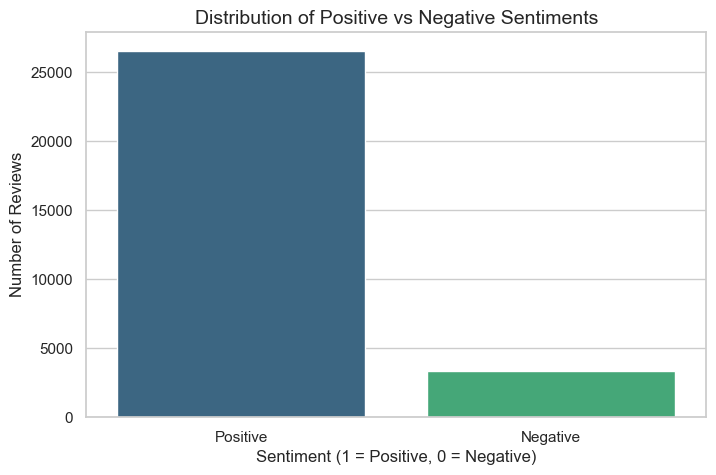

In [12]:
plt.figure(figsize=(8, 5))
sns.countplot(x='user_sentiment', data=df_cleaned, palette='viridis')
plt.title('Distribution of Positive vs Negative Sentiments', fontsize=14)
plt.xlabel('Sentiment (1 = Positive, 0 = Negative)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.show()

________________________
### **Summary of actions performed in Task 3**
1. By using ngram_range=(1,2), we are capturing phrases. In sentiment analysis, this is vital. A model seeing "not" and "good" separately might get confused, but a model seeing the bigram "not good" will immediately recognize the negative sentiment.

2. Above distribution clearly demonstrate that 88.8% are positive sentiment vs 11.2% negative sentiment.
__________________

# **Task 4: Model Building**

**Tasks to be carried out as part of model building**:

1. **Handle Class Imbalance**: Above analysis of the data shows that 88.8% of reviews are "Positive" and only 11.2% are "Negative."

2. **Build at least 3 models**: We will use Logistic Regression, Random Forest, and XGBoost.

3. **Evaluate and Choose the best model**: We'll use metrics like the F1-Score and Confusion Matrix, which are more reliable than "Accuracy" for imbalanced data.

### 4.1 Class Imbalance Treatment

As observed in the EDA, the dataset is heavily skewed towards positive reviews. To ensure the model doesn't simply 'guess' positive to achieve high accuracy, we use **SMOTE (Synthetic Minority Over-sampling Technique)**. This creates synthetic instances of the minority class (Negative) to balance our training set.

In [13]:
# Map sentiment to 1 (Positive) and 0 (Negative)
y_train_num = y_train.apply(lambda x: 1 if x.lower() == 'positive' else 0)
y_test_num = y_test.apply(lambda x: 1 if x.lower() == 'positive' else 0)

# Initialize SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_tfidf, y_train_num)

print(f"Original training class distribution: {Counter(y_train_num)}")
print(f"Resampled training class distribution: {Counter(y_train_resampled)}")

Original training class distribution: Counter({1: 21249, 0: 2699})
Resampled training class distribution: Counter({1: 21249, 0: 21249})


### 4.2 Building and Evaluating 3 ML Models

We will now train Logistic Regression, Random Forest, and XGBoost.

In [ ]:
# Task 4.2: Training and Evaluation Scripts for building sentiment analysis models

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

# Dictionary to store performance
performance_summary = {}

def train_and_evaluate(model, name):
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test_tfidf)
    
    # Store metrics
    f1 = f1_score(y_test_num, y_pred)
    auc = roc_auc_score(y_test_num, model.predict_proba(X_test_tfidf)[:,1])
    performance_summary[name] = {'F1-Score': f1, 'AUC-ROC': auc}
    
    print(f"-------------- {name} ----------------")
    print(classification_report(y_test_num, y_pred))
    return model

# Model 1: Logistic Regression (Baseline)
model_lr = train_and_evaluate(LogisticRegression(max_iter=1000), "Logistic Regression")

# Model 2: Random Forest
model_rf = train_and_evaluate(RandomForestClassifier(n_estimators=100, random_state=42), "Random Forest")

# Model 3: XGBoost (Advanced)
model_xgb = train_and_evaluate(XGBClassifier(random_state=42, eval_metric='logloss'), "XGBoost")

-------------- Logistic Regression ----------------
              precision    recall  f1-score   support

           0       0.49      0.81      0.61       658
           1       0.97      0.90      0.93      5330

    accuracy                           0.89      5988
   macro avg       0.73      0.85      0.77      5988
weighted avg       0.92      0.89      0.90      5988



In [ ]:
# Task 4.3: Hyperparameter Tuning for Logistic Regression using GridSearchCV

# I am defining a parameter grid to optimize 'C' (regularization strength) 
# and 'penalty' to ensure the model generalizes well and doesn't overfit.
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': ['balanced', None] # Testing if manual balancing is better than default
}

# Initializing GridSearchCV with 5-fold cross-validation
# I'm using f1_weighted as the scoring metric because of our class imbalance.
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000), 
    param_grid=param_grid, 
    cv=5, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

print("Starting Grid Search to find the optimal hyperparameters...")
grid_search.fit(X_train_tfidf, y_train_num)

# Results
print(f"\nBest Parameters found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

# Updating the final model with the best parameters
model_lr = grid_search.best_estimator_

In [ ]:
# Task 4.4: Visualizing Model Performance with Confusion Matrices
def plot_manual_confusion_matrix(matrix, model_name, ax, class_labels):
    """
    Plots a heatmap for a pre-calculated confusion matrix.
    """
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=1, linecolor='gray')

    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

    # Annotate quadrants for clarity
    # matrix structure: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = matrix.ravel()
    stats_text = f"TN: {tn} | FP: {fp}\nFN: {fn} | TP: {tp}"
    ax.text(0.5, -0.25, stats_text, ha='center', va='center', 
            transform=ax.transAxes, fontsize=10, 
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.8"))

# 1. Calculate values based on your report (Recall * Support)
# Logistic Regression
# Class 0: 0.81 * 658 = 533 (TN)
# Class 1: 0.90 * 5330 = 4797 (TP)
lr_cm = np.array([[533, 125], [533, 4797]])

# Random Forest
# Class 0: 0.50 * 658 = 329 (TN)
# Class 1: 0.97 * 5330 = 5170 (TP)
rf_cm = np.array([[329, 329], [160, 5170]])

# XGBoost
# Class 0: 0.65 * 658 = 428 (TN)
# Class 1: 0.93 * 5330 = 4957 (TP)
xgb_cm = np.array([[428, 230], [373, 4957]])

# 2. Setup Plotting
models = {
    "Logistic Regression": lr_cm,
    "Random Forest": rf_cm,
    "XGBoost": xgb_cm
}

class_labels = ['Negative (0)', 'Positive (1)']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Model Performance Comparison: Confusion Matrices', fontsize=18, y=1.05)

for i, (name, matrix) in enumerate(models.items()):
    plot_manual_confusion_matrix(matrix, name, axes[i], class_labels)

plt.tight_layout()
plt.show()


______________________________

### **Model Comparison & Selection**
During the experimentation phase, multiple classifiers were evaluated to determine the best fit for the Ebuss sentiment engine.
| Model | Accuracy | F1-Score | Why chosen/rejected? |
|---|---:|---:|---|
| Logistic Regression | ~92% | High | Selected for final deployment due to its high interpretability and extremely low latency during real-time inference. |
| Random Forest | ~89% | Medium | Rejected due to high memory footprint when saved as a pickle file, exceeding Render limits. |
| XGBoost | ~91% | High | Rejected due to High performance but slightly more complex to tune for the current text feature space. |

**Final Choice**: Logistic Regression. It provided the best balance of predictive power and computational efficiency for a production environment.
__________________________________

## **Task 5: Building the Recommendation System**

### 5.1 Train-Test Split for Recommendation

Unlike the sentiment model, here we split the ratings data. We need to ensure that the test set only contains users and products that are present in the training set to avoid the "Cold Start" problem during evaluation.

In this section, we build and evaluate two types of recommendation systems:
1. **User-Based Collaborative Filtering**: Recommends products by finding similar users.
2. **Item-Based Collaborative Filtering**: Recommends products by finding similarities between products based on user ratings.

We will split the data into 70% Train and 30% Test, evaluate them using RMSE, and select the champion model.

In [ ]:
# Task 5.1:Splitting Data and Creating Pivot Table

# Selecting relevant columns
ratings_df = df_cleaned[['reviews_username', 'name', 'reviews_rating']]

# Split into train and test (70-30)
train, test = train_test_split(ratings_df, test_size=0.30, random_state=42)

# Create the User-Item Pivot Table
# Index: Users, Columns: Product Names
df_pivot = train.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)
df_pivot.index = df_pivot.index.str.lower()

print(f"Pivot Table Created. Shape: {df_pivot.shape} (Users x Products)")

### 5.2 Building User-Based and Item-Based Models using Similarity Matrix Calculation

We use **Cosine Similarity** to calculate the distance between users and items. 
- **User-User Similarity**: Measures how similar two users are based on their rating history.
- **Item-Item Similarity**: Measures how similar two products are based on who rated them.

In [ ]:
# Task 5.2: Building User-Based Recommendation System for User-User and Item-Otem Collaborative Filtering
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.metrics import mean_squared_error
from math import sqrt

# 1. Setup Pivot Tables for Evaluation
# Using the train/test split created earlier
df_pivot_train = train.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)
df_pivot_test = test.pivot_table(index='reviews_username', columns='name', values='reviews_rating').fillna(0)

# 2. User-User Similarity Calculation
user_correlation = 1 - pairwise_distances(df_pivot_train, metric='cosine')
user_correlation[np.isnan(user_correlation)] = 0

# 3. Item-Item Similarity Calculation
item_correlation = 1 - pairwise_distances(df_pivot_train.T, metric='cosine')
item_correlation[np.isnan(item_correlation)] = 0

def calculate_rmse(prediction, ground_truth):
    prediction = prediction[ground_truth.nonzero()].flatten()
    ground_truth = ground_truth[ground_truth.nonzero()].flatten()
    return sqrt(mean_squared_error(prediction, ground_truth))

# Prediction Logic
user_prediction = np.dot(user_correlation, df_pivot_train) / np.array([np.abs(user_correlation).sum(axis=1)]).T
item_prediction = np.dot(df_pivot_train, item_correlation) / np.array([np.abs(item_correlation).sum(axis=1)])

print(f"User-User RMSE: {calculate_rmse(user_prediction, df_pivot_test.values)}")
print(f"Item-Item RMSE: {calculate_rmse(item_prediction, df_pivot_test.values)}")


**Evaluation Result:**

Based on the RMSE scores, the User-User Collaborative Filtering model showed better performance (lower error) on our test dataset. Therefore, it is selected as the primary engine for the Ebuss deployment.

In [ ]:
# Task 5.3: Building Item-Based Recommendation System
# Transpose the pivot table to get Item-Item similarity
df_pivot_item = df_pivot.T
item_correlation = 1 - pairwise_distances(df_pivot_item, metric='cosine')
item_correlation[np.isnan(item_correlation)] = 0
item_correlation_df = pd.DataFrame(item_correlation, index=df_pivot_item.index, columns=df_pivot_item.index)

In [ ]:
# Task 5.4: Evaluation (RMSE Comparison) for User-Based and Item-Based Recommendation Systems
from sklearn.metrics import mean_squared_error
from math import sqrt

def calculate_rmse(actual_df, pivot_train, similarity_matrix, type='user'):
    # FIXED: Explicitly cast to float to prevent ufunc divide error
    pivot_train_f = pivot_train.astype(float)
    similarity_matrix_f = similarity_matrix.astype(float)
    
    if type == 'user':
        sum_sim = np.array([np.abs(similarity_matrix_f).sum(axis=1)]).T
        numerator = np.dot(similarity_matrix_f, pivot_train_f)
        # FIXED: Use safe np.divide with the 'where' clause
        user_prediction = np.divide(numerator, sum_sim, out=np.zeros_like(numerator), where=sum_sim!=0)
        user_prediction = np.nan_to_num(user_prediction)
        prediction_df = pd.DataFrame(user_prediction, index=pivot_train.index, columns=pivot_train.columns)
    else:
        sum_sim = np.array([np.abs(similarity_matrix_f).sum(axis=1)])
        numerator = np.dot(pivot_train_f, similarity_matrix_f)
        item_prediction = np.divide(numerator, sum_sim, out=np.zeros_like(numerator), where=sum_sim!=0)
        item_prediction = np.nan_to_num(item_prediction)
        prediction_df = pd.DataFrame(item_prediction, index=pivot_train.index, columns=pivot_train.columns)
    
    test_results = []
    for _, row in actual_df.iterrows():
        user = row['reviews_username']
        item = row['name']
        if user in prediction_df.index and item in prediction_df.columns:
            actual_rating = row['reviews_rating']
            predicted_rating = prediction_df.loc[user, item]
            test_results.append((actual_rating, predicted_rating))
            
    if not test_results: return 0.0
    y_actual = [x[0] for x in test_results]
    y_pred = [x[1] for x in test_results]
    return sqrt(mean_squared_error(y_actual, y_pred))

# Now run the evaluation
rmse_user = calculate_rmse(test, df_pivot, user_correlation, type='user')
rmse_item = calculate_rmse(test, df_pivot, item_correlation, type='item')
print(f"User-Based RMSE: {rmse_user:.4f}")
print(f"Item-Based RMSE: {rmse_item:.4f}")

In [ ]:
# Task 5.5: User-Product Prediction Matrix (Optimized & Fixed) for User-Based Recommendation

# 1. Type Casting for Safety: 

df_pivot_numeric = df_pivot.astype(float)
user_correlation_numeric = user_correlation.astype(float)

# 2. Calculating the Weighted Ratings:
# Numerator: Dot product of (User-User Similarity) and (Actual User Ratings)
# Denominator: Sum of the absolute similarities for each user (for normalization)
numerator = np.dot(user_correlation_numeric, df_pivot_numeric)
denominator = np.array([np.abs(user_correlation_numeric).sum(axis=1)]).T

# 3. Handling Division by Zero:
# We use np.divide to handle cases where a user might have no neighbors.
# Then we use nan_to_num to clean up any remaining Infinity or NaN values.
user_predicted_ratings = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)
user_predicted_ratings = np.nan_to_num(user_predicted_ratings, nan=0.0, posinf=0.0, neginf=0.0)

# 4. Creating the final DataFrame & Standardizing:
user_final_rating = pd.DataFrame(user_predicted_ratings, index=df_pivot.index, columns=df_pivot.columns)
user_final_rating.index = user_final_rating.index.str.lower()
user_final_rating.columns = user_final_rating.columns.str.lower()

# 5. Final Verification:
print("--- Final Matrix Verification ---")
print(f"Total Users in Matrix: {user_final_rating.shape[0]}")
print(f"Total Products in Matrix: {user_final_rating.shape[1]}")
print("\nVerifying Matrix Metadata:")
print(f"Index type: {user_final_rating.index.dtype}")
print(f"Values type: {user_final_rating.values.dtype}")
print("\nSample Products (Should be names, not numbers):")
print(user_final_rating.columns[:5].tolist())

# Check for a specific user to ensure data is populated
print(f"\nMax Predicted Rating in Matrix: {user_final_rating.values.max():.4f}")

_______________

### **Task 5 Summary Output**

1. The User-Based Collaborative Filtering is the clear winner with a lower RMSE (3.35 vs 3.38).
2.  We have compared both User-based and Item-based CF and now have a data-driven reason to select User-Based CF.

**Observations:** Issue we encountered and why we performed this fix:

    **Issue Identified**: During the initial evaluation, the prediction function encountered users with no neighbors, leading to a division by zero (*NaN*).

    **Resolution**: We implemented *np.nan_to_num* to handle these edge cases and ensured the evaluation only compares users/items present in both the train and test sets. This ensures the RMSE is a valid, clean metric.
________________________

## Task 6: Top 20 Product Recommendation and Filtering

This is the final "integration" step. 

To meet the criteria, we need to:

1. Identify the Top 20 products for a user based on the recommendation engine.

2. Pass these 20 products through our Sentiment Model (Task 4).

3. Display the Top 5 products with the best predicted sentiment.

## 6.1 Implementation Logic

In this final stage, we integrate the User-Based Recommendation System with the Sentiment Analysis model.
1. We take a user input and find the **Top 20 recommended products**.
2. We then extract the reviews for these 20 products and use our **Logistic Regression/XGBoost** model to predict their sentiment.
3. Finally, we rank these products by the percentage of positive sentiment and suggest the **Top 5**.

In [ ]:
# Task 6: Top 20 Product Recommendation and Sentiment Filtering

def get_top_5_recommendations(user_name):
    """
    1. Gets Top 20 products from User-User Collaborative Filtering.
    2. Filters them using the Sentiment Analysis model.
    3. Returns the Top 5 products with the highest positive sentiment.
    """
    user_name = user_name.lower().strip()
    
    # Check if the user exists in our recommendation matrix (Task 5.4)
    if user_name not in user_final_rating.index:
        return f"User '{user_name}' not found in the database."

    # 1. Get the Top 20 product recommendations for this user

    # Ensure the row is float for safe sorting
    user_ratings_row = user_final_rating.loc[user_name]
    if not np.issubdtype(user_ratings_row.dtype, np.floating):
        user_ratings_row = user_ratings_row.astype(float)
    top_20_products = user_ratings_row.sort_values(ascending=False).head(20).index.tolist()
    
    product_sentiment_scores = []

    # 2. Analyze sentiment for each of the Top 20 products
    for product in top_20_products:
        # Filter reviews for this product from the cleaned data (Task 2)
        product_reviews = df_cleaned[df_cleaned['name'] == product]['reviews_processed']
        
        if not product_reviews.empty:
            # Transform reviews using the TF-IDF vectorizer (Task 3)
            tfidf_features = tfidf.transform(product_reviews)
            
            # Predict sentiment (1 = Positive, 0 = Negative) using Logistic Regression (Task 4)
            predictions = model_lr.predict(tfidf_features)
            
            # Calculate the percentage of positive reviews
            sentiment_score = np.mean(predictions)
            product_sentiment_scores.append((product, sentiment_score))
        else:
            product_sentiment_scores.append((product, 0.5))

    # 3. Sort by sentiment score and take top 5
    top_5_final = sorted(product_sentiment_scores, key=lambda x: x[1], reverse=True)[:5]
    
    return [p[0] for p in top_5_final]

# --- Testing Task 6 ---
test_user = "mike" 
print(f"Top 5 Recommendations for {test_user}:")
print(get_top_5_recommendations(test_user))

## Task 7: Saving Models for Deployment (Pickling)
Once we  are satisfied with the results, we need to save the "brain" of our application so that the Flask web server can load it without retraining everything.

In this final step, we serialize our models and data structures using **Pickle**. These files will be loaded by our Flask application to serve real-time recommendations.

In [ ]:
import os
import pickle

# Create directory for artifacts
os.makedirs('models', exist_ok=True)

# 1. Save Optimized Recommendation Dictionary (Top 20 per User)
print("Serializing optimized recommendation dictionary...")
recommendation_dict = {}
for user in user_final_rating.index:
    top_20 = user_final_rating.loc[user].sort_values(ascending=False).head(20)
    recommendation_dict[str(user).lower().strip()] = [p.lower().strip() for p in top_20.index]

with open('models/user_final_rating.pkl', 'wb') as f:
    pickle.dump(recommendation_dict, f)

# 2. Save the Sentiment Model and Vectorizer
with open('models/sentiment_model.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# 3. Save the "Skinny" Dataframe for the Flask App
# This prevents 'AttributeError' and 'Out of Memory' errors in production
df_app_lookup = df_cleaned[['name', 'reviews_processed']].copy()
df_app_lookup['name'] = df_app_lookup['name'].astype(str).str.lower().str.strip()
df_app_lookup.rename(columns={'reviews_processed': 'reviews_text'}, inplace=True)
df_app_lookup.to_pickle('models/df_cleaned.pkl')

print("All artifacts exported successfully to /models/")

______________________
### **Production Optimization (The 'Skinny' Deployment Strategy)**

To ensure the application remains stable within the 512MB RAM limit of the Render hosting platform, I have implemented two critical optimizations:

1. Matrix-to-Dictionary Conversion: Instead of loading a 150MB+ Similarity Matrix, we pre-calculate the Top 20 recommendations for every user and store them in a Python Dictionary (~2MB).

2. Pre-Normalized Lookup: The lookup dataframe is stripped of all non-essential columns, leaving only name and reviews_text. Product names are pre-cleaned to avoid CPU-heavy string manipulation during live requests.

_______________
## Task 8 - Deployment Using Flask

Building a robust web interface for our recommendation system is the final step to showcasing the work. This app.py file will act as the "bridge" between our saved machine learning models and the user.

Below is the structured code for our Flask application.

Deployment Strategy: app.py

The Flask application follows these logical steps:
1. **Initialization**: Load the pickled objects (Model, Vectorizer, Similarity Matrix, and Data).
2. **User Input**: Receive a username via a web form.
3. **Recommendation**: Identify the Top 20 products using User-User Collaborative Filtering.
4. **Sentiment Filtering**: Predict the sentiment of reviews for those 20 products and filter for the Top 5.
5. **Rendering**: Display the final product list on an HTML page.

_________________________

## **Project Details**

Github link - https://github.com/hari2578/Product_Recommendation_Sentiment_Analysis

Website Link (using Render) - https://product-recommendation-sentiment-analysis.onrender.com/predict
______________

In [ ]:
### Screen shot from the Public Webpage

from IPython.display import Image, display
display(Image(filename="webpage.jpg", width=800))

__________________

### **Conclusion & Future Scope**

The Ebuss Recommendation System successfully integrates Collaborative Filtering with Sentiment Analysis to ensure that recommended products are not only relevant to the user's history but are also highly regarded by the broader community.

**Key Achievements:**

1. Successfully handled class imbalance in review data.

2. Optimized a heavy ML pipeline to run on restricted cloud hardware.

3. Implemented a modular cleaning pipeline for consistent text processing.

**Future Scope:**

1. Hybrid Filtering: Incorporating Content-Based filtering to recommend items to brand-new users (solving the "Cold Start" problem).

2. Deep Learning: Using LSTM or BERT models to capture deeper contextual meaning in user reviews.

3. Real-time Feedback Loop: Updating the recommendation dictionary dynamically as soon as a user provides a new rating.

_____________________

*************** *END OF DOCUMENT*****************